# Task 1: Business Sales Performance Analytics
**Future Interns – Data Science & Analytics Track**

**Objective:** Analyze business sales data to identify revenue trends, top-selling products, high-value categories, and regional performance.

**Tools used:** Python (Pandas, Matplotlib, Seaborn)

**Deliverable:** A client-ready analysis with clear insights and actionable recommendations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


## 1. Load the Data

In [2]:
df = pd.read_csv("../data/sales_data.csv", parse_dates=["OrderDate"])
print(df.shape)
df.head()


(6010, 15)


,OrderID,OrderDate,CustomerID,CustomerSegment,Region,Category,Product,UnitPrice,Quantity,DiscountPct,GrossRevenue,DiscountAmount,NetRevenue,PaymentMethod,IsReturned
0,ORD104162,2023-01-01,CUST03586,Returning,West,Electronics,Wireless Earbuds,30.21,6,0,181.26,0.0,181.26,Debit Card,0
1,ORD100755,2023-01-01,CUST02240,VIP,West,Electronics,Smart Watch,90.31,3,0,270.93,0.0,270.93,UPI,0
2,ORD103556,2023-01-01,CUST03258,VIP,South,Home & Kitchen,Vacuum Cleaner,103.98,5,5,519.90,26.0,493.90,Debit Card,0
3,ORD105177,2023-01-01,CUST02881,VIP,East,Apparel,Denim Jacket,91.75,4,0,367.00,0.0,367.00,UPI,0
4,ORD100648,2023-01-01,CUST02409,Returning,South,Beauty & Personal Care,Skincare Kit,72.36,3,0,217.08,0.0,217.08,Credit Card,0


## 2. Initial Data Inspection

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6010 entries, 0 to 6009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          6010 non-null   str           
 1   OrderDate        6010 non-null   datetime64[us]
 2   CustomerID       6010 non-null   str           
 3   CustomerSegment  6010 non-null   str           
 4   Region           6010 non-null   str           
 5   Category         6010 non-null   str           
 6   Product          6010 non-null   str           
 7   UnitPrice        6000 non-null   float64       
 8   Quantity         6010 non-null   int64         
 9   DiscountPct      6010 non-null   int64         
 10  GrossRevenue     6010 non-null   float64       
 11  DiscountAmount   6010 non-null   float64       
 12  NetRevenue       6010 non-null   float64       
 13  PaymentMethod    6010 non-null   str           
 14  IsReturned       6010 non-null   int64         
dty

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
OrderID,6010,6000,ORD102185,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OrderDate,6010,NaN,NaN,NaN,2024-01-02 16:20:41.131447,2023-01-01 00:00:00,2023-07-04 00:00:00,2024-01-04 00:00:00,2024-07-06 00:00:00,2024-12-31 00:00:00,NaN
CustomerID,6010,3057,CUST03193,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerSegment,6010,3,New,2708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,6010,9,West,1317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,6010,5,Electronics,1713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,6010,25,Smart Watch,371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,6000.0,NaN,NaN,NaN,94.91827,5.14,47.7275,83.135,134.9525,249.75,58.340606
Quantity,6010.0,NaN,NaN,NaN,4.297005,-1.0,3.0,4.0,6.0,18.0,1.971711
DiscountPct,6010.0,NaN,NaN,NaN,4.224626,0.0,0.0,0.0,5.0,20.0,6.158941


## 3. Data Cleaning

Before analysis, we handle common real-world data issues:
- Inconsistent text casing (e.g. `north` vs `North`)
- Missing values in `UnitPrice`
- Invalid negative `Quantity` values
- Duplicate order records


In [5]:
# Standardize categorical text fields
df["Region"] = df["Region"].str.strip().str.title()
df["Category"] = df["Category"].str.strip()
df["Product"] = df["Product"].str.strip()

# Check missing values
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])


Missing values per column:
UnitPrice    10
dtype: int64


In [6]:
# Fill missing UnitPrice using the median price for that Category
df["UnitPrice"] = df.groupby("Category")["UnitPrice"].transform(
    lambda x: x.fillna(x.median())
)

# Remove invalid negative quantities
before = len(df)
df = df[df["Quantity"] > 0]
print(f"Removed {before - len(df)} rows with invalid quantity")


Removed 7 rows with invalid quantity


In [7]:
# Drop exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# Recompute revenue fields to guarantee consistency after cleaning
df["GrossRevenue"] = (df["UnitPrice"] * df["Quantity"]).round(2)
df["DiscountAmount"] = (df["GrossRevenue"] * df["DiscountPct"] / 100).round(2)
df["NetRevenue"] = (df["GrossRevenue"] - df["DiscountAmount"]).round(2)

df["OrderMonth"] = df["OrderDate"].dt.to_period("M").astype(str)
df["OrderYear"] = df["OrderDate"].dt.year

print(df.shape)
df.head()


Removed 10 duplicate rows
(5993, 17)


,OrderID,OrderDate,CustomerID,CustomerSegment,Region,Category,Product,UnitPrice,Quantity,DiscountPct,GrossRevenue,DiscountAmount,NetRevenue,PaymentMethod,IsReturned,OrderMonth,OrderYear
0,ORD104162,2023-01-01,CUST03586,Returning,West,Electronics,Wireless Earbuds,30.21,6,0,181.26,0.0,181.26,Debit Card,0,2023-01,2023
1,ORD100755,2023-01-01,CUST02240,VIP,West,Electronics,Smart Watch,90.31,3,0,270.93,0.0,270.93,UPI,0,2023-01,2023
2,ORD103556,2023-01-01,CUST03258,VIP,South,Home & Kitchen,Vacuum Cleaner,103.98,5,5,519.90,26.0,493.90,Debit Card,0,2023-01,2023
3,ORD105177,2023-01-01,CUST02881,VIP,East,Apparel,Denim Jacket,91.75,4,0,367.00,0.0,367.00,UPI,0,2023-01,2023
4,ORD100648,2023-01-01,CUST02409,Returning,South,Beauty & Personal Care,Skincare Kit,72.36,3,0,217.08,0.0,217.08,Credit Card,0,2023-01,2023


## 4. Key Business KPIs

In [8]:
total_revenue = df["NetRevenue"].sum()
total_orders = df["OrderID"].nunique()
avg_order_value = df.groupby("OrderID")["NetRevenue"].sum().mean()
return_rate = df["IsReturned"].mean() * 100

print(f"Total Net Revenue:      ${total_revenue:,.2f}")
print(f"Total Orders:           {total_orders:,}")
print(f"Average Order Value:    ${avg_order_value:,.2f}")
print(f"Return Rate:            {return_rate:.2f}%")


Total Net Revenue:      $2,339,908.54
Total Orders:           5,993
Average Order Value:    $390.44
Return Rate:            5.96%


## 5. Revenue Trend Over Time

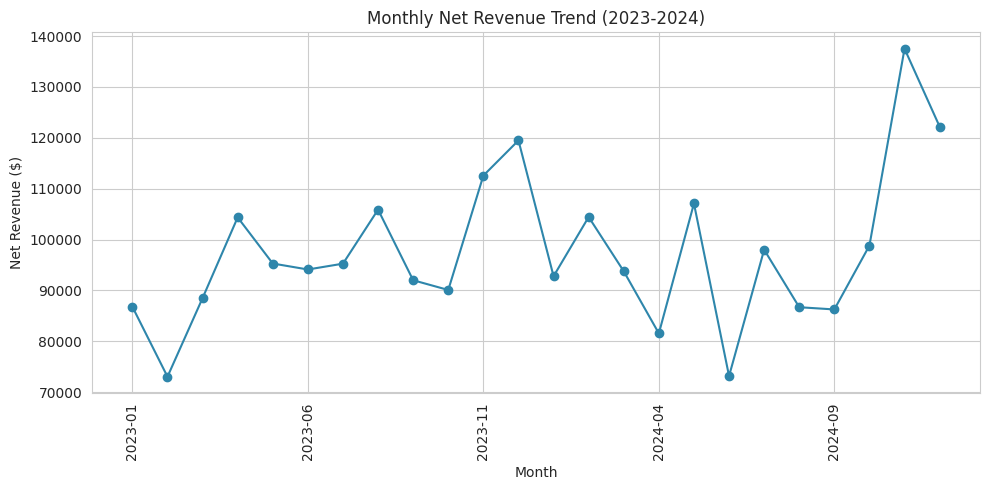

In [9]:
monthly_revenue = df.groupby("OrderMonth")["NetRevenue"].sum().sort_index()

plt.figure()
monthly_revenue.plot(kind="line", marker="o", color="#2E86AB")
plt.title("Monthly Net Revenue Trend (2023-2024)")
plt.xlabel("Month")
plt.ylabel("Net Revenue ($)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../outputs/monthly_revenue_trend.png", dpi=150)
plt.show()


**Insight:** Revenue shows a clear upward trend into November/December of each year, consistent with holiday-season demand, alongside overall year-over-year growth.

## 6. Top-Selling Products

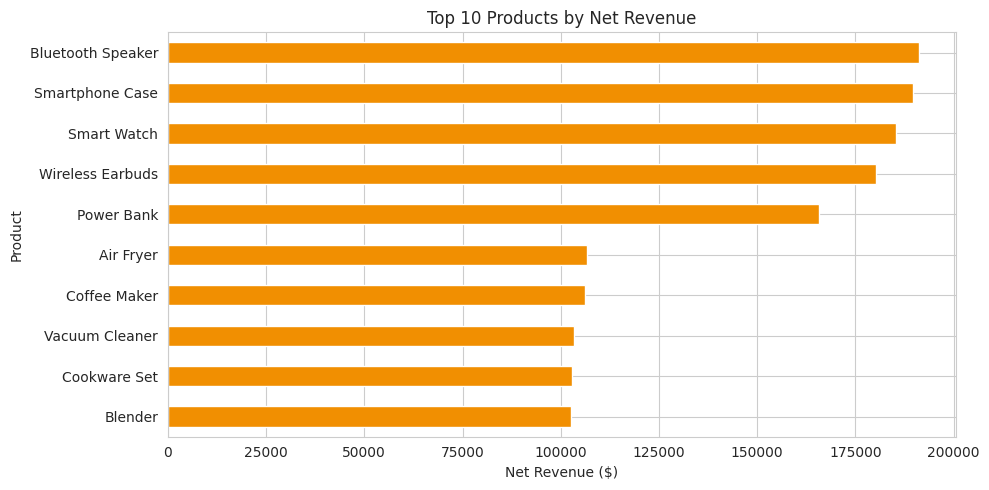

Product
Bluetooth Speaker    191110.43
Smartphone Case      189755.05
Smart Watch          185382.84
Wireless Earbuds     180262.21
Power Bank           165672.24
Air Fryer            106661.52
Coffee Maker         106258.64
Vacuum Cleaner       103367.10
Cookware Set         102891.34
Blender              102610.21
Name: NetRevenue, dtype: float64

In [10]:
top_products = (
    df.groupby("Product")["NetRevenue"].sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
top_products.sort_values().plot(kind="barh", color="#F18F01")
plt.title("Top 10 Products by Net Revenue")
plt.xlabel("Net Revenue ($)")
plt.tight_layout()
plt.savefig("../outputs/top_products.png", dpi=150)
plt.show()

top_products


## 7. High-Value Categories

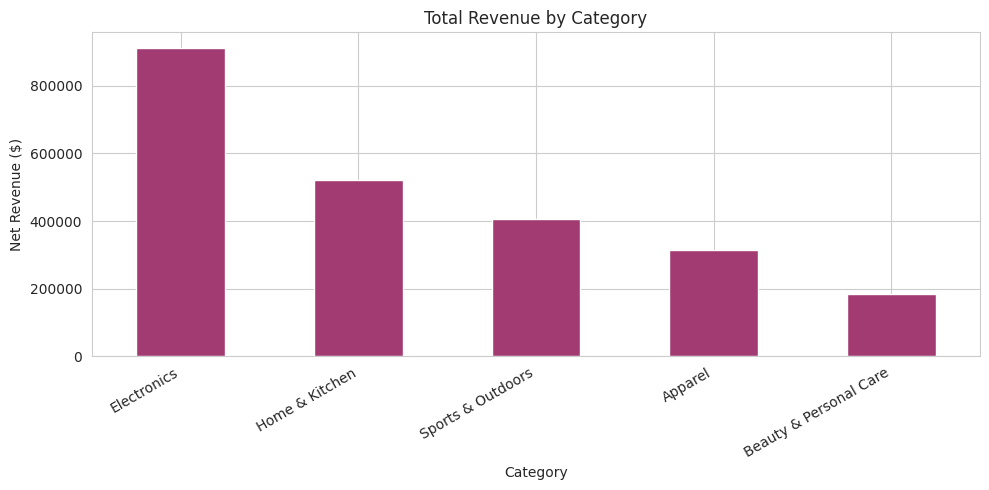

,TotalRevenue,Orders,AvgOrderValue
Category,,,
Electronics,912182.77,1707,534.377721
Home & Kitchen,521788.81,1282,407.011552
Sports & Outdoors,405757.61,904,448.846914
Apparel,314421.85,1175,267.593064
Beauty & Personal Care,185757.50,925,200.818919


In [11]:
category_revenue = (
    df.groupby("Category")
    .agg(TotalRevenue=("NetRevenue", "sum"),
         Orders=("OrderID", "nunique"),
         AvgOrderValue=("NetRevenue", "mean"))
    .sort_values("TotalRevenue", ascending=False)
)

plt.figure()
category_revenue["TotalRevenue"].plot(kind="bar", color="#A23B72")
plt.title("Total Revenue by Category")
plt.ylabel("Net Revenue ($)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../outputs/category_revenue.png", dpi=150)
plt.show()

category_revenue


## 8. Regional Performance

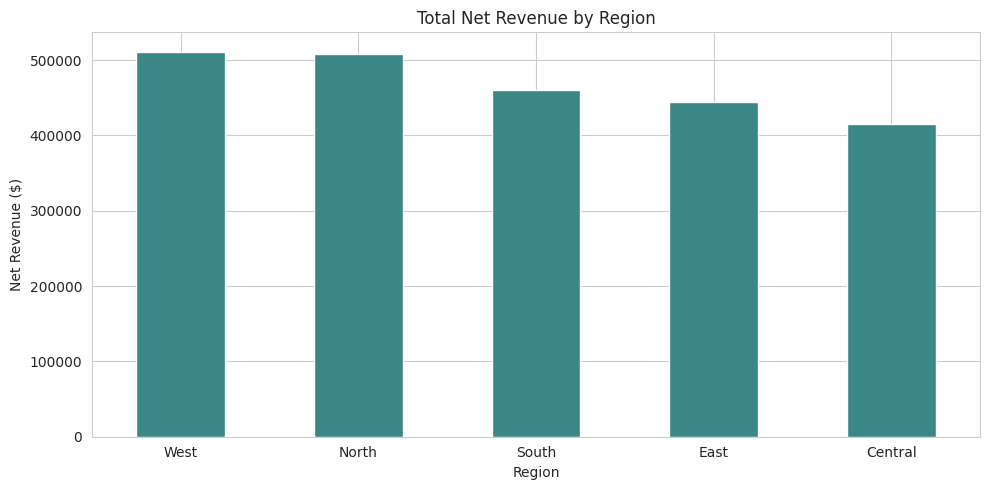

Region
West       511333.81
North      508070.52
South      460686.96
East       444006.81
Central    415810.44
Name: NetRevenue, dtype: float64

In [12]:
regional_revenue = (
    df.groupby("Region")["NetRevenue"].sum().sort_values(ascending=False)
)

plt.figure()
regional_revenue.plot(kind="bar", color="#3B8686")
plt.title("Total Net Revenue by Region")
plt.ylabel("Net Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/regional_revenue.png", dpi=150)
plt.show()

regional_revenue


## 9. Revenue by Customer Segment

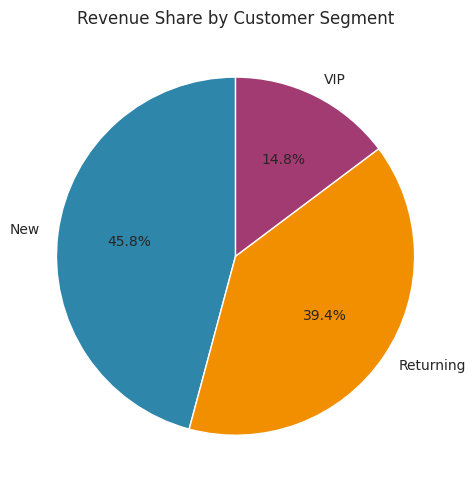

In [13]:
segment_revenue = df.groupby("CustomerSegment")["NetRevenue"].sum().sort_values(ascending=False)

plt.figure()
segment_revenue.plot(kind="pie", autopct="%1.1f%%", startangle=90,
                      colors=["#2E86AB", "#F18F01", "#A23B72"])
plt.ylabel("")
plt.title("Revenue Share by Customer Segment")
plt.tight_layout()
plt.savefig("../outputs/segment_revenue.png", dpi=150)
plt.show()


## 10. Payment Method Preferences

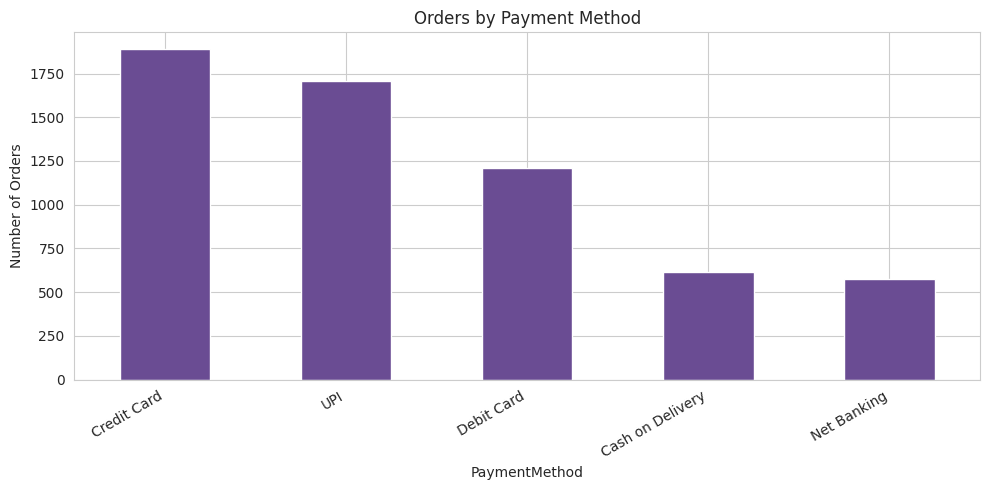

In [14]:
payment_counts = df["PaymentMethod"].value_counts()

plt.figure()
payment_counts.plot(kind="bar", color="#6A4C93")
plt.title("Orders by Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../outputs/payment_methods.png", dpi=150)
plt.show()


## 11. Key Insights

1. **Seasonality drives revenue** — Nov/Dec consistently outperform other months, indicating strong holiday-driven demand.
2. **Category concentration** — Electronics and Home & Kitchen generate the largest share of revenue, suggesting these should receive priority inventory and marketing investment.
3. **Regional imbalance** — Revenue is not evenly distributed across regions; underperforming regions represent untapped growth opportunity.
4. **Customer segment value** — VIP customers, while the smallest segment by count, contribute disproportionately high average order value.
5. **Digital payments dominate** — Credit Card and UPI are the leading payment methods, reflecting a digitally-driven customer base.

## 12. Actionable Recommendations

- **Plan inventory and staffing ahead of Nov–Dec** to capture peak seasonal demand without stockouts.
- **Double down on top-performing categories** (Electronics, Home & Kitchen) with targeted promotions and cross-sell bundles.
- **Launch region-specific campaigns** in lower-performing regions to close the revenue gap (e.g., localized discounts, regional influencers).
- **Build a VIP loyalty program** to increase retention and order frequency among high-value customers.
- **Optimize checkout for leading payment methods** (Credit Card, UPI) to reduce friction and improve conversion.

---
*Prepared as part of the Future Interns Data Science & Analytics Internship — Task 1.*
